# Load and Explore the dataset

In [ ]:
import pandas as pd
import numpy as np

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)


df = pd.read_csv("/content/ai_learning_lab.csv")

print(f" shape: {df.shape}")
print(f"First five rows : \n{df.head(5)}")
print(f"columns : {df.columns.tolist()}")

 shape: (110, 12)
First five rows : 
  student_id    student_name      batch         topic attendance  assignment_score  quiz_score lab_completed  \
0      ST001      Rakesh P    AIML-2603          JSON    PRESENT              -5.0       -10.0           yes   
1      ST002    Aarav Sharma  AIML-2602    SQL Basics     ABSENT              68.0        65.0            no   
2      ST003  Harsha Vardhan  AIML-2605           EDA    PRESENT              35.0        68.0            No   
3      ST004       Sirisha P  AIML-2605           eda    present              96.0        27.0           YES   
4      ST005     Yashwanth K  AIML-2603  NumPy Basics    Absent               56.0        94.0          Yes    

   study_hours  feedback_rating  tool_used api_used  
0          8.6              3.0    VS Code       No  
1          9.8              4.0     colab       yes  
2          4.7              3.0     colab       Yes  
3          NaN              3.0   jupyter       yes  
4          4.7      

In [ ]:
print(f"data types: {df.info()}")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        110 non-null    object 
 1   student_name      110 non-null    object 
 2   batch             110 non-null    object 
 3   topic             110 non-null    object 
 4   attendance        110 non-null    object 
 5   assignment_score  98 non-null     float64
 6   quiz_score        102 non-null    float64
 7   lab_completed     110 non-null    object 
 8   study_hours       101 non-null    float64
 9   feedback_rating   104 non-null    float64
 10  tool_used         110 non-null    object 
 11  api_used          110 non-null    object 
dtypes: float64(4), object(8)
memory usage: 10.4+ KB
data types: None


In [ ]:
print(f"missing value count : {df.isna().sum()}")

missing value count : student_id           0
student_name         0
batch                0
topic                0
attendance           0
assignment_score    12
quiz_score           8
lab_completed        0
study_hours          9
feedback_rating      6
tool_used            0
api_used             0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df['topic'].value_counts()

,count
topic,
Loops,10
Python Basics,9
pandas loading,9
eda,8
Pandas Filtering,7
Decision Making,6
JSON,6
EDA,6
Functions,5


In [ ]:
df['attendance'].value_counts()

,count
attendance,
ABSENT,16
Present,16
Absent,15
PRESENT,15
Present,15
Absent,14
present,10
absent,9


# Task 2 — Clean and Prepare the Dataset

In [ ]:
df[['student_name','topic','tool_used','attendance','lab_completed','api_used']] = (
    df[['student_name','topic','tool_used','attendance','lab_completed','api_used']]
    .apply(lambda col: col.str.strip())
)


In [ ]:
# Clean text first, THEN drop duplicates -- this catches duplicates that only
# differ by whitespace/casing, not just byte-for-byte identical rows.
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
df[['attendance','lab_completed','api_used']].apply(lambda col : print(f" :{col.unique()}"))


 :['PRESENT' 'ABSENT' 'present' 'Absent' 'Present' 'absent']
 :['yes' 'no' 'No' 'YES' 'Yes' 'NO']
 :['No' 'yes' 'Yes' 'no' 'YES' 'NO']


,0
attendance,None
lab_completed,None
api_used,None


In [ ]:
# .title() is fine for simple Yes/No/Present/Absent columns, but it mangles
# acronyms like "EDA" -> "Eda", "JSON" -> "Json", "SQL Basics" -> "Sql Basics".
# So: title-case the simple columns, and use an explicit map for topic/tool_used.

df[['attendance','lab_completed','api_used']] = (
    df[['attendance','lab_completed','api_used']].apply(lambda col: col.str.title())
)

topic_map = {
    'json': 'JSON', 'sql basics': 'SQL Basics', 'eda': 'EDA', 'numpy basics': 'NumPy Basics',
    'pandas loading': 'Pandas Loading', 'loops': 'Loops', 'python basics': 'Python Basics',
    'decision making': 'Decision Making', 'pandas filtering': 'Pandas Filtering',
    'functions': 'Functions', 'ai landscape': 'AI Landscape', 'matplotlib': 'Matplotlib',
    'pandas grouping': 'Pandas Grouping', 'apis and ethics': 'APIs and Ethics',
    'data collections': 'Data Collections', 'file handling': 'File Handling'
}
df['topic'] = df['topic'].str.lower().map(topic_map).fillna(df['topic'])

tool_map = {'vs code': 'VS Code', 'colab': 'Colab', 'jupyter': 'Jupyter'}
df['tool_used'] = df['tool_used'].str.lower().map(tool_map).fillna(df['tool_used'])

df['attendance'].unique()

array(['Present', 'Absent'], dtype=object)

In [ ]:
df.loc[df['assignment_score']<0,'assignment_score'] = np.nan
df.loc[df['assignment_score']>100,'assignment_score'] = np.nan
df['assignment_score'].isna().sum()

np.int64(15)

In [ ]:
df.loc[df['quiz_score']<0,'quiz_score'] = np.nan
df.loc[df['quiz_score']>100,'quiz_score'] = np.nan
df['quiz_score'].isna().sum()

np.int64(14)

In [ ]:
df.loc[df['study_hours']<0,'study_hours']= np.nan
df.loc[df['feedback_rating']<1,'feedback_rating'] = np.nan
df.loc[df['feedback_rating']>5,'feedback_rating'] = np.nan

In [ ]:

df.isna().sum()

,0
student_id,0
student_name,0
batch,0
topic,0
attendance,0
assignment_score,15
quiz_score,14
lab_completed,0
study_hours,11
feedback_rating,9


In [ ]:
df.fillna({'assignment_score' : df['assignment_score'].mean(),
           'quiz_score'       : df['quiz_score'].mean(),
           'study_hours'      : df['study_hours'].median(),
           'feedback_rating'  : df['feedback_rating'].median()
           }, inplace = True)

In [ ]:
print(f"shape after cleaning : {df.shape}")
print(f"missing value count : \n{df.isna().sum()} ")
df.to_csv("cleaned_ai_learning_lab.csv", index=False)


shape after cleaning : (105, 12)
missing value count : 
student_id          0
student_name        0
batch               0
topic               0
attendance          0
assignment_score    0
quiz_score          0
lab_completed       0
study_hours         0
feedback_rating     0
tool_used           0
api_used            0
dtype: int64 


In [ ]:
df.duplicated().sum()

np.int64(0)

# Task 3 — Analyze the Learning Data

In [ ]:
df = pd.read_csv("/content/cleaned_ai_learning_lab.csv")

In [ ]:
df['total_score'] = (df['assignment_score'] + df['quiz_score']).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        105 non-null    object 
 1   student_name      105 non-null    object 
 2   batch             105 non-null    object 
 3   topic             105 non-null    object 
 4   attendance        105 non-null    object 
 5   assignment_score  105 non-null    float64
 6   quiz_score        105 non-null    float64
 7   lab_completed     105 non-null    object 
 8   study_hours       105 non-null    float64
 9   feedback_rating   105 non-null    float64
 10  tool_used         105 non-null    object 
 11  api_used          105 non-null    object 
 12  total_score       105 non-null    int64  
dtypes: float64(4), int64(1), object(8)
memory usage: 10.8+ KB


In [ ]:
def condition(x) :
  if x >= 160 :
    return 'Excellent'
  elif 120 <= x <= 159 :
    return 'Good'
  elif 80 <= x <= 119 :
    return 'Average'
  elif x < 80 :
    return 'Needs Support'
df['performance_level'] = df['total_score'].apply(condition)
df.groupby(df['performance_level'])['total_score'].min()

,total_score
performance_level,
Average,83
Excellent,161
Good,122
Needs Support,67


In [ ]:
df.columns

Index(['student_id', 'student_name', 'batch', 'topic', 'attendance', 'assignment_score', 'quiz_score', 'lab_completed',
       'study_hours', 'feedback_rating', 'tool_used', 'api_used', 'total_score', 'performance_level'],
      dtype='object')

In [ ]:
print(f"average assignment score : {df['assignment_score'].mean()}")
print(f"average quize score : {df['quiz_score'].mean()}")
print(f"average study hours : {df['study_hours'].mean()}\n")

x = df.groupby(['performance_level']).agg(student_count = ('student_id','count'))
print(f"number of students in each performance level : \n {x}\n")
print(f" topic-wise average score \n{df.groupby(['topic'])['total_score'].mean()}\n")
print(f" batch-wise average score\n{df.groupby(['batch'])['total_score'].mean()}\n")
print(f"Students who are marked as need support : \n{df[df['performance_level'] == 'Needs Support']['student_name']}")

average assignment score : 66.85555555555555
average quize score : 63.20879120879121
average study hours : 6.206190476190476

number of students in each performance level : 
                    student_count
performance_level               
Average                       34
Excellent                     14
Good                          55
Needs Support                  2

 topic-wise average score 
topic
AI Landscape        133.600000
APIs and Ethics     127.375000
Data Collections    136.500000
Decision Making     121.500000
EDA                 125.461538
File Handling       115.000000
Functions           108.400000
JSON                112.000000
Loops               141.700000
Matplotlib          162.500000
NumPy Basics        151.500000
Pandas Filtering    122.571429
Pandas Grouping     135.800000
Pandas Loading      122.416667
Python Basics       142.833333
SQL Basics          126.000000
Name: total_score, dtype: float64

 batch-wise average score
batch
AIML-2601    135.578947
AIML-2

#Task 4 — Visualize and Export the Report

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Global chart defaults — run this once, applies to everything below (Run Commands Parameters is a dictionary of Matplotlib Configuration settings)
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# Shared palette and named colors — we'll use these throughout
PALETTE = sns.color_palette("Set2")
ORANGE  = "#E67E22"
BLUE    = "#2980B9"
RED     = "#E74C3C"
GREEN   = "#27AE60"

In [ ]:
df = pd.read_csv("/content/cleaned_ai_learning_lab.csv")

In [ ]:
df.columns.to_list()

['student_id',
 'student_name',
 'batch',
 'topic',
 'attendance',
 'assignment_score',
 'quiz_score',
 'lab_completed',
 'study_hours',
 'feedback_rating',
 'tool_used',
 'api_used']

In [ ]:
df['total_score'] = (df['assignment_score'] + df['quiz_score']).astype(int)

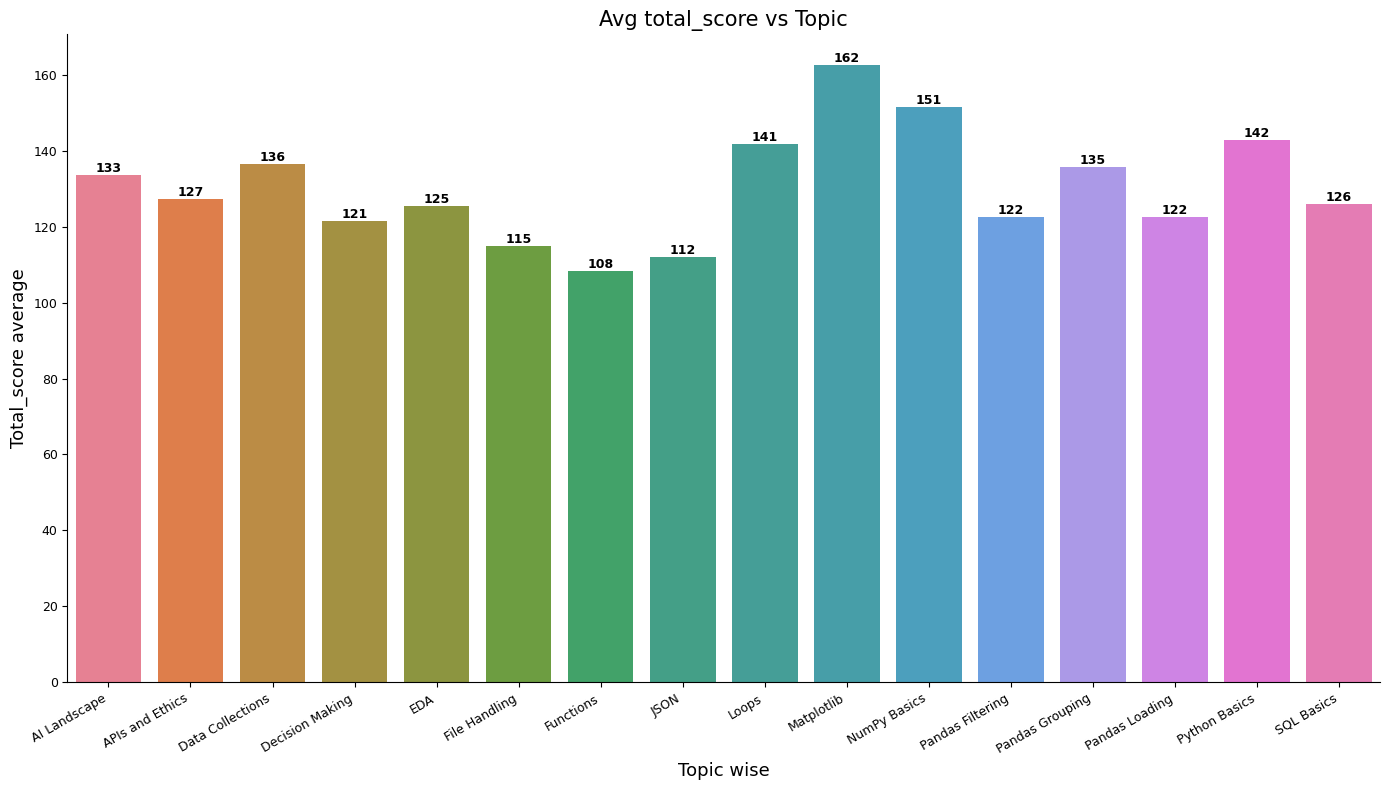

In [110]:
fig, ax = plt.subplots(figsize=(14,8))
df1 = df.groupby('topic').agg(avg_tota_score = ('total_score','mean')).reset_index()

sns.barplot(df1,x = 'topic', y = 'avg_tota_score', hue = 'topic', ax = ax )
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0,
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )
ax.set_title("Avg total_score vs Topic")
ax.set_ylabel("Total_score average")
ax.set_xlabel("Topic wise")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("topic_score_chart.png")
plt.show()

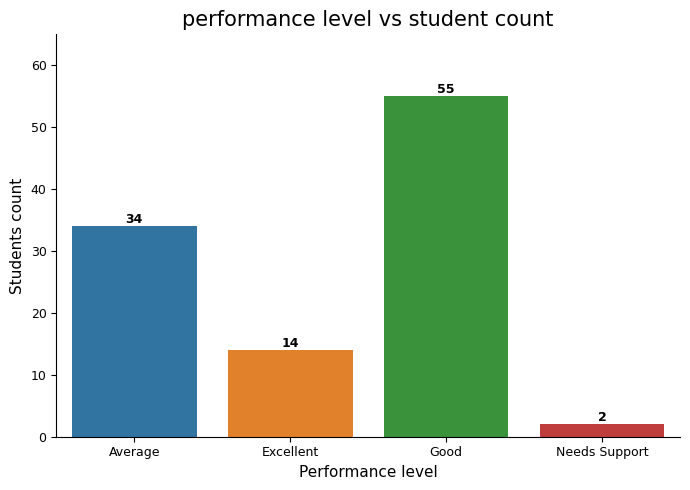

In [106]:
def condition(x) :
  if x >= 160 :
    return 'Excellent'
  elif 120 <= x <= 159 :
    return 'Good'
  elif 80 <= x <= 119 :
    return 'Average'
  elif x < 80 :
    return 'Needs Support'
df['performance_level'] = df['total_score'].apply(condition)
df2 = df.groupby('performance_level'). agg(student_count = ('student_name','count')).reset_index()

fig, ax = plt.subplots(figsize = (7,5))
sns.barplot(df2, x = 'performance_level', y = 'student_count',hue = 'performance_level', ax = ax)

for bar in ax.patches:
  ax.text(
      bar.get_x() + bar.get_width()/2,
      bar.get_height() + 0,
      f'{int(bar.get_height()):,}',
      ha = 'center',
      va = 'bottom',
      fontsize=9,
      fontweight='bold'
       )

ax.set_title("performance level vs student count")
ax.set_ylabel("Students count")
ax.set_xlabel("Performance level")
ax.set_ylim(ymax=df2['student_count'].max() + 10)
plt.tight_layout()
plt.savefig("performance_level_chart.png")
plt.show()

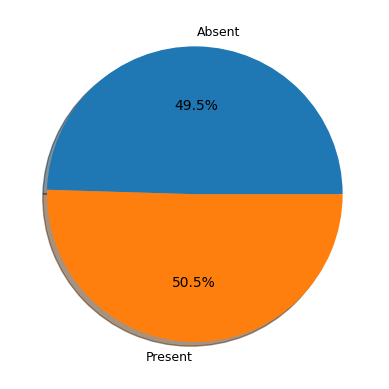

In [111]:
df3 = df.groupby('attendance').agg(student_count = ("student_id", 'count')).reset_index()

plt.pie(df3['student_count'], labels = df3['attendance'],autopct="%1.1f%%",shadow=True)
plt.savefig("attendance_chart.png")
plt.show()

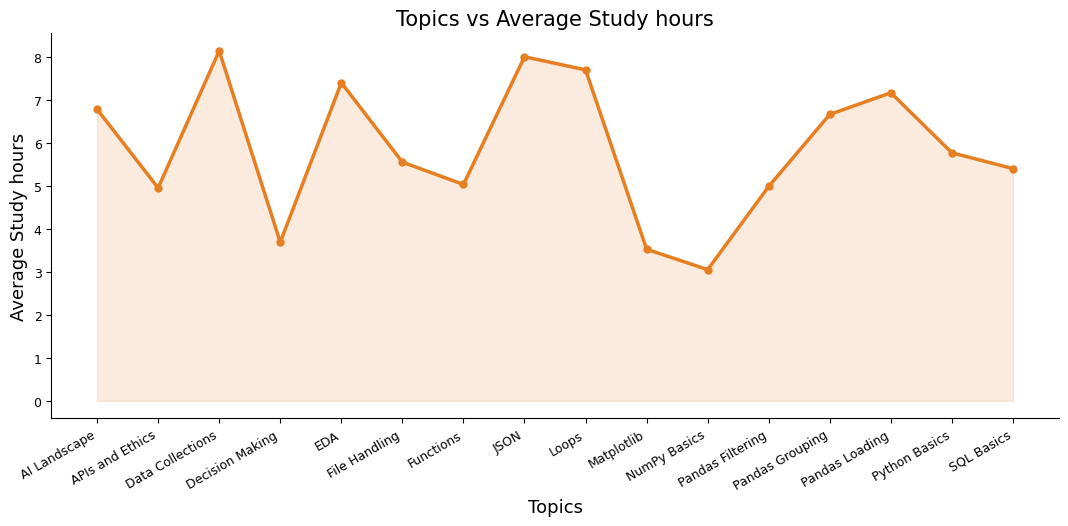

In [112]:
fig, ax = plt.subplots(figsize = (13,5))
df4 = df.groupby('topic').agg(study_hours_avg = ('study_hours','mean')).reset_index()


ax.plot(df4['topic'], df4['study_hours_avg'],
        color=ORANGE, linewidth=2.5,marker="o", markersize=5, zorder=3)
ax.fill_between(df4['topic'], df4['study_hours_avg'], alpha=0.15, color=ORANGE)
ax.set_title("Topics vs Average Study hours")
ax.set_ylabel("Average Study hours")
ax.set_xlabel("Topics")
plt.xticks(rotation = 30, ha = 'right')
plt.savefig('study_hours_chart.png')
plt.show()


# Creating JSON file

In [103]:
import json

summary = {
    "Total number of students": len(df),
    "Average assignment score": round(float(df['assignment_score'].mean()), 2),
    "Average quiz score": round(float(df['quiz_score'].mean()), 2),
    "Average study hours": round(float(df['study_hours'].mean()), 2),
    "Most common topic": df['topic'].mode()[0]
}

with open("learning_summary.json", "w") as file :
  json.dump(summary,file,indent = 4)


In [ ]:
print(df['topic'].value_counts().nlargest(1))


topic
Eda    13
Name: count, dtype: int64


# Task 5 - Optional Bonus Task — Simple SQLite Querying

In [ ]:
import pandas as pd
import sqlite3

student_table = pd.read_csv("/content/cleaned_ai_learning_lab.csv")

# total_score wasn't saved into the cleaned CSV, so add it here before
# loading into SQLite -- otherwise Query 3 below has no column to reference.
student_table['total_score'] = (student_table['assignment_score'] + student_table['quiz_score']).round().astype(int)

conn = sqlite3.connect("learning_lab.db")
cursor = conn.cursor()

student_table.to_sql("student_learning", conn, index = False, if_exists = "replace")

'''Query 1: Average assignment score by topic'''

query1 =  ''' SELECT topic, AVG(assignment_score)
              FROM student_learning
              GROUP BY topic'''

'''Query 2: Student count by batch'''

query2 = '''SELECT batch, COUNT(*)
            FROM student_learning
            GROUP BY batch'''


'''Query 3: Students with total score below 80'''

query3 = ''' SELECT student_name, total_score
             FROM student_learning
             WHERE total_score < 80'''


result = pd.read_sql(query1,conn)  # cursor.execute(query1)
print(f" Average assignment score by topic : ")
print("=="*30)                    # print(cursor.fetchall())
print(result)
print("=="*30)
result = pd.read_sql(query2,conn)   # cursor.execute(query2)
print(f" \nStudent count by batch : ")
print("=="*30)                  # print(cursor.fetchall())
print(result)
print("=="*30)
result = pd.read_sql(query3,conn)  # cursor.execute(query3)
print(f" \nStudents with total score below 80 :")
print("=="*30)
print(result)
print("=="*30)                     # print(cursor.fetchall())

 Average assignment score by topic : 
               topic  AVG(assignment_score)
0       Ai Landscape              70.000000
1    Apis And Ethics              65.231944
2   Data Collections              69.463889
3    Decision Making              72.500000
4                Eda              66.604274
5      File Handling              56.666667
6          Functions              61.742222
7               Json              69.971111
8              Loops              74.056667
9         Matplotlib              80.713889
10      Numpy Basics              61.427778
11  Pandas Filtering              68.142857
12   Pandas Grouping              55.971111
13    Pandas Loading              58.583333
14     Python Basics              74.892593
15        Sql Basics              56.809259
 
Student count by batch : 
       batch  COUNT(*)
0  AIML-2601        19
1  AIML-2602        20
2  AIML-2603        25
3  AIML-2604        24
4  AIML-2605        17
 
Students with total score below 80 :
  student